In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
plt.rcParams['axes.unicode_minus'] = False
from PIL import Image 
from torchvision import transforms as  T 
import os 
import SimpleITK
import sys 
from transformers import ViTFeatureExtractor, ViTForImageClassification


In [2]:
model_id = '../model/vit/'
label2id = {str(k) : v for (k, v) in enumerate(range(5))}
id2label = {v : k for (k, v) in label2id.items()}
feature_extractor = ViTFeatureExtractor.from_pretrained(model_id)
model = ViTForImageClassification.from_pretrained(
    model_id,  # classification head
    num_labels=5, 
    label2id = label2id,
    id2label = id2label
)

/home/kathy/anaconda3/envs/hkx/lib/python3.8/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at ../model/vit/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [2]:
def get_pixels_hu_by_simpleitk(dicom_dir):
    '''
        获取某文件夹内所有dicom文件的像素值
    :param src_dir: dicom文件夹路径
    :return: image array
    '''
    reader = SimpleITK.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(dicom_dir)
    reader.SetFileNames(dicom_names)
    image = reader.Execute()
    img_array = SimpleITK.GetArrayFromImage(image)
    img_array[img_array == -2000] = 0
    return img_array


In [43]:

img = Image.open('/home/kathy/projects/project_guo/train/image/1_0.png')

In [45]:
img_path='/home/kathy/projects/project_guo/train/image/'
img_files = [img_path + i for  i in  os.listdir(img_path)]

In [47]:
for i in img_files:
    img = Image.open(i)
    mask = Image.open(i.replace("image", "mask"))
    if mask.size[0] != img.size[0]:
        print(mask.size, img.size)
    # print(img.size)

In [4]:
transforms = T.Compose([
    T.ToTensor()
])

In [6]:
img = transforms(img) 

In [9]:
img.shape 

torch.Size([1, 256, 256])

In [11]:
img.max()

tensor(1.)

In [9]:
len(os.listdir('/home/kathy/projects/project_guo/train/mask/'))

647

In [18]:
train_img = transforms(Image.open('/home/kathy/projects/project_guo/train/image/1_0.png'))

In [19]:
train_img.shape

torch.Size([1, 256, 256])

In [32]:
train_target = transforms(Image.open('/home/kathy/projects/project_guo/train/mask/1_9.png'))

In [42]:
import torch 
(train_target.unique() * 4).ceil()

tensor([0., 1., 2., 3., 4.])

In [12]:
arr = get_pixels_hu_by_simpleitk('/home/kathy/dataset/CHAOS/Test_Sets/MR/11/T1DUAL/DICOM_anon/InPhase') 
print(arr.shape)

(26, 256, 256)


In [14]:
np.unique(arr).shape 

(1626,)

In [15]:
arr.max()

1819

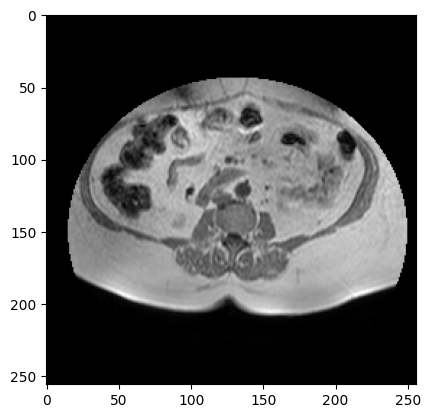

In [9]:
plt.imshow(arr[0], cmap="gray")